# Entraînement des Modèles d'IA : Prédiction des Émissions de CO2
Ce notebook rassemble l'ensemble de notre pipeline de machine learning. L'objectif est de prédire les émissions totales de CO2 (variable cible) à partir de caractéristiques d'une ville ("signatures urbaines" : noeuds, arêtes, densité, rayon spectral, constante de Kreiss) et de la charge de trafic (nombre de véhicules).

Comme expliqué dans la documentation, nous comparons plusieurs modèles d'IA pour identifier le plus performant.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Préparation & Évaluation
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Modèles
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\thoma\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\thoma\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\thoma\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\thoma\anaconda3\Lib\site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\thoma\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\thoma\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\thoma\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\thoma\anaconda3\Lib\site-pack

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [2]:
# --- 1. CHARGEMENT DES DONNÉES ---
# Attention : Actuellement, le jeu de données est restreint, ce script est prévu 
# pour s'adapter dynamiquement lorsque nous ajouterons plus de villes.
data_path = 'data/dataset_complet.csv'
try:
    df_raw = pd.read_csv(data_path)
    # On supprime les villes sans features spectrales (comme Amsterdam ou Cairo pour le moment)
    df = df_raw.dropna()
    print("Données brutes totales :", len(df_raw))
    print("Données valides pour entraînement :", len(df))
    display(df.head())
except Exception as e:
    print(f"Erreur lors du chargement de {data_path} : {e}")


Données brutes totales : 10
Données valides pour entraînement : 10


,city,simulation_file,total_vehicles,total_co2_kg,avg_speed_mps,n_nodes,n_edges,density,spectral_radius,kreiss_constant
0,amsterdam,amsterdam5k_20260203_214119.csv,5000,942.998643,4.404440,7088,16073,0.000320,4.552776,30.463092
1,berlin,berlin10K_20260114_102317.csv,10000,1665.356205,4.040104,8855,21043,0.000268,4.271558,0.000210
2,buenos_aires,buenos_aires20k_20260204_092533.csv,20000,23052.782677,12.274315,2820,5637,0.000709,4.000000,45.431267
3,cairo,cairo20k_20260204_102859.csv,20000,200874.578178,15.149746,13095,29575,0.000172,4.570664,32.496154
4,dubai,dubai30k_20260204_130916.csv,30000,145810.271024,13.273491,3841,6476,0.000439,4.123115,30.331502


In [3]:
# --- 2. PRÉPARATION DES DONNÉES (FEATURES & TARGET) ---
# Nos features (X) : les informations structurelles, spectrales et le volume de trafic
# Notre cible (y) : The total_co2_kg

# On retire les colonnes non prédictives (identifiants, cibles alternatives)
columns_to_drop = ['city', 'simulation_file', 'total_co2_kg', 'avg_speed_mps']
X = df.drop(columns=columns_to_drop)
y = df['total_co2_kg']

print("Features utilisées :", X.columns.tolist())

# Normalisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Si nous avons plus de quelques lignes, nous pouvons faire un train_test_split.
# Pour l'instant (5 lignes), ce fractionnement est symbolique ou peut échouer l'entraînement complexe.
# Nous prévoyons le code ici :
if len(df) > 10:
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
else:
    print("Attention: Jeu de données trop petit pour un split robuste. Validation sur l'ensemble complet (overfitting assumé).")
    X_train, X_test, y_train, y_test = X_scaled, X_scaled, y, y


Features utilisées : ['total_vehicles', 'n_nodes', 'n_edges', 'density', 'spectral_radius', 'kreiss_constant']
Attention: Jeu de données trop petit pour un split robuste. Validation sur l'ensemble complet (overfitting assumé).


In [4]:
# --- 3. DÉFINITION DES MODÈLES D'IA ---
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Neural Network (MLP)': MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
}


In [5]:
# --- 4. ENTRAÎNEMENT ET ÉVALUATION ---
results = {}

print(f"{'Modèle':<25} | {'RMSE':<10} | {'MAE':<10} | {'R2 Score':<10}")
print("-" * 65)

for name, model in models.items():
    # Entraînement
    model.fit(X_train, y_train)
    
    # Prédiction
    y_pred = model.predict(X_test)
    
    # Calcul des métriques
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Model': model}
    
    print(f"{name:<25} | {rmse:<10.2f} | {mae:<10.2f} | {r2:<10.2f}")


Modèle                    | RMSE       | MAE        | R2 Score  
-----------------------------------------------------------------
Linear Regression         | 10568.01   | 8963.63    | 0.98      
Ridge Regression          | 23982.99   | 21097.44   | 0.88      
Random Forest             | 27510.06   | 15117.32   | 0.84      
Gradient Boosting         | 2.38       | 2.11       | 1.00      


Neural Network (MLP)      | 66016.02   | 32747.01   | 0.06      


C:\Users\thoma\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


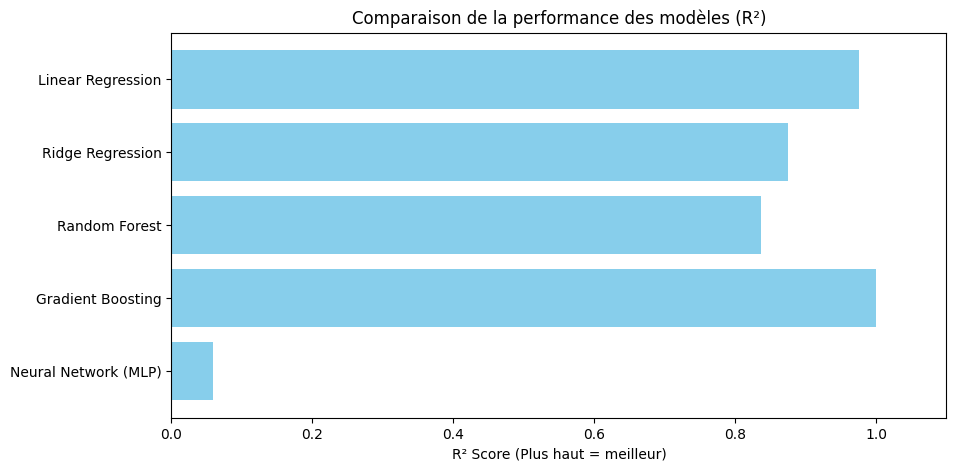

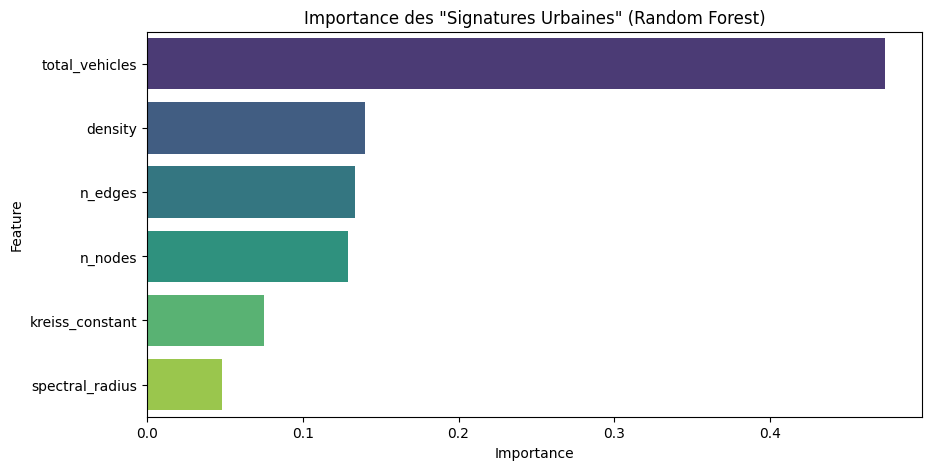

In [6]:
# --- 5. VISUALISATIONS ---
# Comparaison des R2 Scores
names = list(results.keys())
r2_scores = [results[n]['R2'] for n in names]

plt.figure(figsize=(10, 5))
plt.barh(names, r2_scores, color='skyblue')
plt.xlabel('R² Score (Plus haut = meilleur)')
plt.title('Comparaison de la performance des modèles (R²)')
plt.xlim(0, 1.1)
plt.gca().invert_yaxis()
plt.show()

# Importance des features pour le Random Forest
rf_model = results['Random Forest']['Model']
importances = rf_model.feature_importances_

feature_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis', hue='Feature', legend=False)
plt.title('Importance des "Signatures Urbaines" (Random Forest)')
plt.show()
